In [3]:
import numpy as np
import matplotlib.pyplot as plt
from utils import (reduce_list_half_preserve_extremes,
                   depths,
                   sem_ids_with_syn_path)

rcpsize = 20
plt.rcParams['xtick.labelsize']= rcpsize
plt.rcParams['ytick.labelsize']=rcpsize
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'STIXGeneral'
plt.rcParams['font.size'] = rcpsize
plt.rcParams.update({'figure.autolayout': True})
#colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
colors = plt.style.library['ggplot']['axes.prop_cycle'].by_key()['color']
colors = plt.style.library['seaborn-v0_8']['axes.prop_cycle'].by_key()['color']
colors = plt.style.library['seaborn-v0_8-dark-palette']['axes.prop_cycle'].by_key()['color']
from cycler import cycler
plt.rcParams['axes.prop_cycle'] = cycler(color=colors)
# print(plt.rcParams.keys())
#np.set_printoptions(precision=None)
markers = ['p','o','h','^','s','*']
_linestyles = ['-','--','dotted']
plot_id = 0


#box = ax.get_position()
#ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])
#ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

space = 'A'
avg_tokens = 1
model_name = "qwen7b"
base_dir = f"results/centroids_correlations/"
sem_ids = np.array(np.loadtxt(sem_ids_with_syn_path,dtype=int),dtype=int) # filtering data to have their syntax group in space A 
Ns = len(sem_ids)

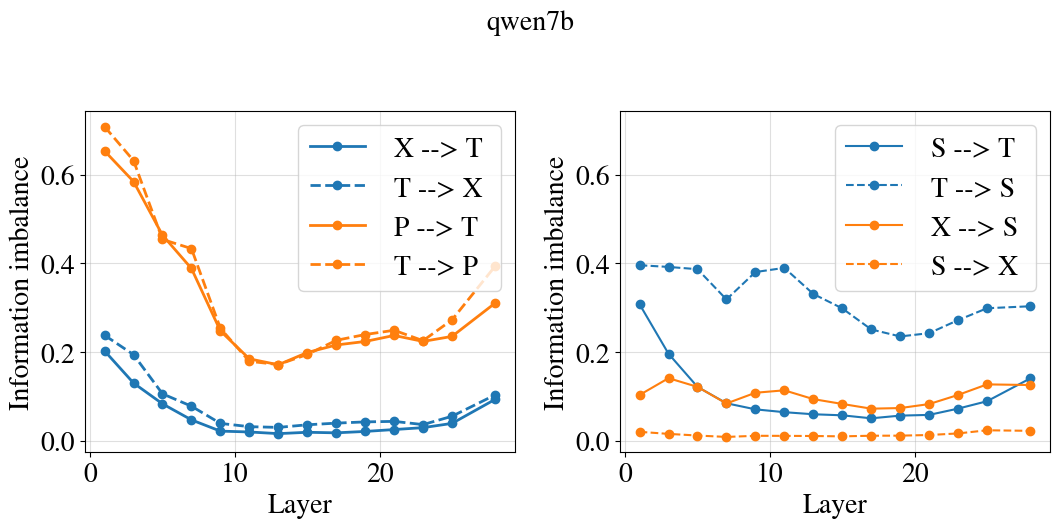

In [2]:
import numpy as np
import matplotlib.pyplot as plt

fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(11, 5.5), sharex=True, sharey=True)
line_styles = ['-','--']
colors = plt.cm.tab10.colors

plot_id_L = 0
for space_id, space in enumerate(['A', 'B']):
    centroids_inf_imb_path = f"{base_dir}/inf_imb_centroids_Ns_{Ns}_avg_{avg_tokens}_{model_name}.txt"
    sem_inf_imb_path = f"{base_dir}/inf_imb_sem_{space}_Ns_{Ns}_avg_{avg_tokens}_{model_name}.txt"
    syn_inf_imb_path = f'{base_dir}/inf_imb_syn_Ns_{Ns}_avg_{avg_tokens}_{model_name}.txt'
    
    # Load data
    centroids_inf_imb = np.loadtxt(centroids_inf_imb_path)
    sem_inf_imb = np.loadtxt(sem_inf_imb_path)
    syn_inf_imb = np.loadtxt(syn_inf_imb_path)
    
    # cosine_path = f"{base_dir}/cos_similarities_Ns_{Ns}_avg_{avg_tokens}_{model_name}.txt"
    # cos_mean, cos_std = np.loadtxt(cosine_path, unpack=True)
    
    layers = list(range(1, depths[model_name] + 1))
    layers = reduce_list_half_preserve_extremes(layers)

    # Left panel
    for II_index in range(2):
        data_index = 'X' if space == 'A' else 'P'
        lbl = f' {data_index} --> T ' if II_index == 0 else f' T --> {data_index} '
        ax_left.plot(
            layers, sem_inf_imb[:, II_index],
            marker='o', 
            lw=2,
            label=lbl,
            linestyle=line_styles[II_index],
            color=colors[plot_id_L],
        )
    plot_id_L += 1

    # Right panel
    if space == 'A':
      for II_index in range(2):
              lbl = f' S --> T ' if II_index == 0 else f' T --> S '
              ax_right.plot(
                  layers, centroids_inf_imb[:, II_index],
                  marker='o',
                  linestyle=line_styles[II_index],
                  color=colors[0],
                  label=lbl,
              )
      for II_index in range(2):
              lbl_syn = f' X --> S ' if II_index == 0 else f' S --> X '
              ax_right.plot(
                  layers, syn_inf_imb[:, II_index],
                  marker='o',
                  linestyle=line_styles[II_index],
                  color=colors[1],
                  label=lbl_syn,
              )


# Restore right y-axis numbers
ax_right.tick_params(labelleft=True)

# Labels, legends, grids
ax_left.set_xlabel("Layer")
ax_left.set_ylabel("Information imbalance")
ax_left.legend()
ax_left.grid(alpha=0.4)

ax_right.set_xlabel("Layer")
ax_right.set_ylabel("Information imbalance")
ax_right.legend()
ax_right.grid(alpha=0.4)

plt.suptitle(f"{model_name}", fontsize=rcpsize)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


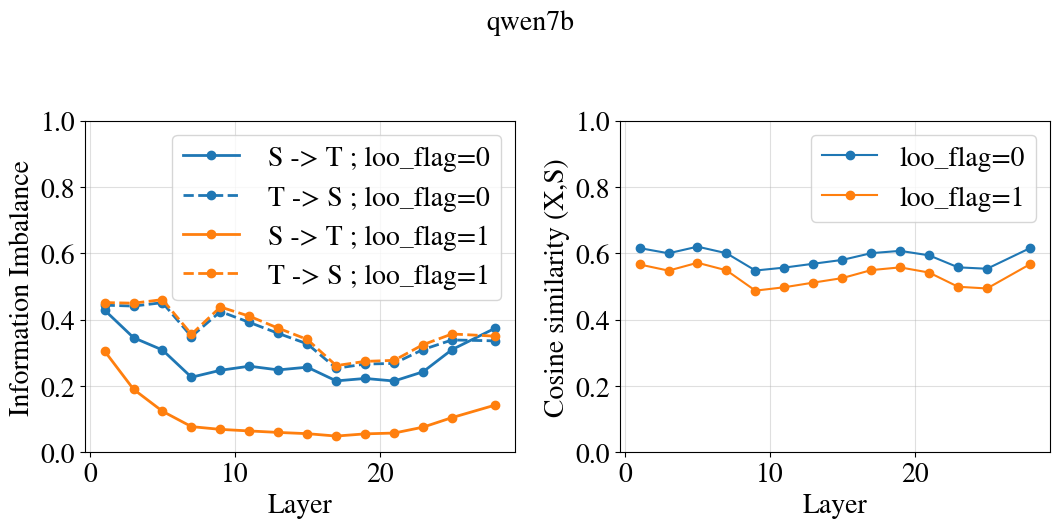

In [17]:
import numpy as np
import matplotlib.pyplot as plt

fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(11, 5.5), sharex=True, sharey=True)
line_styles = ['-','--']
colors = plt.cm.tab10.colors

plot_id_L = 0
plot_id_R = 0
space = 'A'
for enum_loo_id, loo_flag in enumerate([0,1]):
    
    centroids_inf_imb_path = f"{base_dir}loo_{loo_flag}/inf_imb_centroids_Ns_{Ns}_avg_{avg_tokens}_{model_name}.txt"
    cosine_path = f"{base_dir}loo_{loo_flag}/cos_similarities_{space}_Ns_{Ns}_avg_{avg_tokens}_{model_name}.txt"
    
    centroids_inf_imb = np.loadtxt(centroids_inf_imb_path)
    cos_mean, cos_std = np.loadtxt(cosine_path, unpack=True)
    
    layers = list(range(1, depths[model_name] + 1))
    layers = reduce_list_half_preserve_extremes(layers)


    # Left panel
    for II_index in range(2):
        lbl = f' S -> T ; {loo_flag=}' if II_index == 0 else f' T -> S ; {loo_flag=}'
        ax_left.plot(
            layers, centroids_inf_imb[:, II_index],
            marker='o', 
            lw=2,
            label=lbl,
            linestyle=line_styles[II_index],
            color=colors[plot_id_L],
        )
    plot_id_L += 1

    # Right panel
    lbl = f'{loo_flag=}'
    ax_right.plot(
        layers, cos_mean,
        marker='o',
        color=colors[plot_id_R],
        label=lbl,
    )
    plot_id_R += 1


# Restore right y-axis numbers
ax_right.tick_params(labelleft=True)

# Labels, legends, grids
ax_left.set_xlabel("Layer")
ax_left.set_ylabel("Information Imbalance")
ax_left.legend()
ax_left.grid(alpha=0.4)

ax_right.set_xlabel("Layer")
ax_right.set_ylabel("Cosine similarity (X,S)")
ax_right.legend()
ax_right.grid(alpha=0.4)

ax_left.set_ylim(0,1)
plt.suptitle(f"{model_name}", fontsize=rcpsize)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


inf_imb.shape=(14, 200, 2)


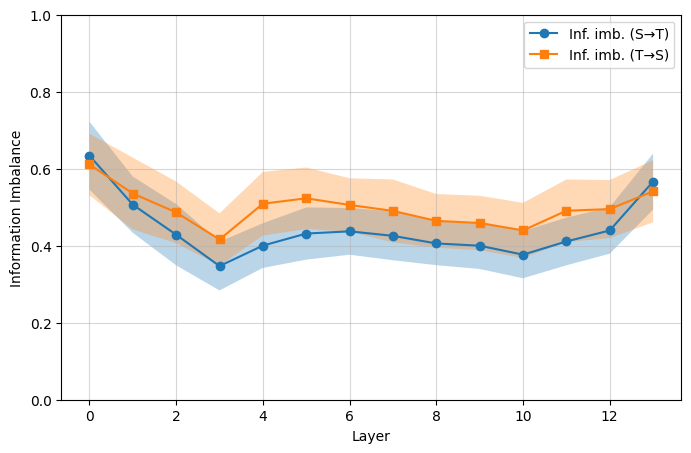

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# --- configuration ---
model_name = 'qwen7b'
avg_tokens = 0
space = 'A'
loo_flag = 1

output_dir = Path(f"results/centroids_correlations/loo_{loo_flag}")
file_path = output_dir / f"inf_imb_centroids_{space}_avg_{avg_tokens}_{model_name}.txt.npy"

# --- load ---
inf_imb = np.load(file_path)  # shape = (n_layers, n_iter, 2)
print(f"{inf_imb.shape=}")

# --- compute means and stds across iterations ---
inf_imb_mean = inf_imb.mean(axis=1)
inf_imb_std = inf_imb.std(axis=1)

# If you also saved or know the list of layer values
# (if not, just make a range)
layer_vals = np.arange(inf_imb.shape[0])

# --- plot ---
plt.figure(figsize=(8, 5))
plt.plot(layer_vals, inf_imb_mean[:, 0], marker='o', label='Inf. imb. (S→T)')
plt.plot(layer_vals, inf_imb_mean[:, 1], marker='s', label='Inf. imb. (T→S)')

plt.fill_between(layer_vals,
                 inf_imb_mean[:, 0] - inf_imb_std[:, 0],
                 inf_imb_mean[:, 0] + inf_imb_std[:, 0],
                 alpha=0.3)
plt.fill_between(layer_vals,
                 inf_imb_mean[:, 1] - inf_imb_std[:, 1],
                 inf_imb_mean[:, 1] + inf_imb_std[:, 1],
                 alpha=0.3)

plt.xlabel("Layer")
plt.ylabel("Information Imbalance")
plt.legend()
plt.grid(alpha=0.5)
plt.ylim(0,1)
plt.show()
